# Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Set the visual style for the plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

In [3]:
df = pd.read_csv('vaccinations_cleaned.csv')

# PREPARING DATA FOR CLUSTERING

## Select Latest Data and Features

In [4]:
# We use the latest available data for each country to get a final snapshot.
latest_data = df.loc[df.groupby('location')['date'].idxmax()].copy()

In [5]:
# Select the features that will define our clusters
feature_cols = [
    'people_fully_vaccinated_per_hundred',
    'total_boosters_per_hundred',
    'daily_vaccinations_per_million'
]

In [6]:
# Create a new DataFrame for clustering, filtering out countries with no data
cluster_df = latest_data[
    (latest_data['people_fully_vaccinated_per_hundred'] > 0) &
    (latest_data['daily_vaccinations_per_million'] > 0)
].copy()

In [7]:
X = cluster_df[feature_cols]

## Scale the Features

In [8]:
# Scaling is crucial for K-Means as it is a distance-based algorithm.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
print(f"Data prepared for clustering with {X_scaled.shape[0]} countries and {X_scaled.shape[1]} features.")

Data prepared for clustering with 181 countries and 3 features.


# FINDING THE OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD)

- We calculate the inertia (within-cluster sum of squares) for different values of K (number of clusters). The "elbow" point on the plot suggests the optimal K.

In [10]:
inertia_scores = []
k_range = range(1, 11)

In [11]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_scores.append(kmeans.inertia_)

## Visualization: Elbow Method Plot

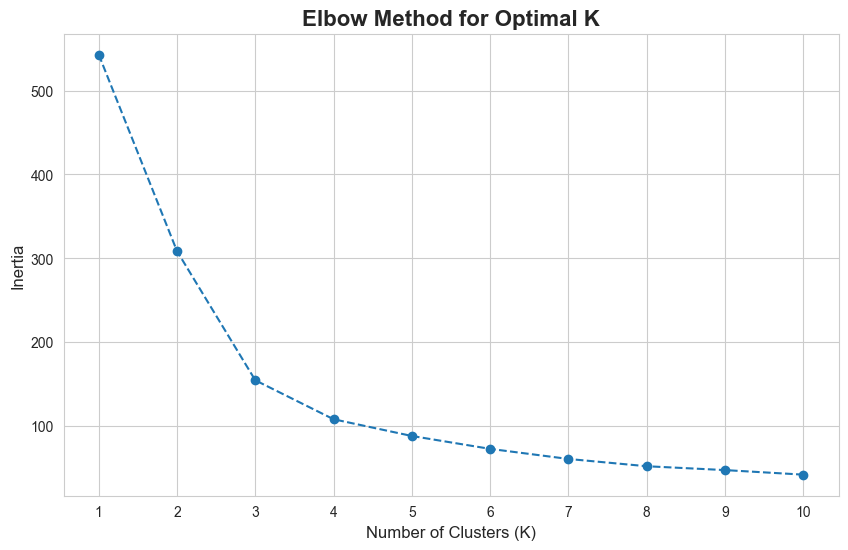

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_scores, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K', fontsize=16, weight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.xticks(k_range)
plt.show()

- Insight: The plot shows a clear 'elbow' at K=3. The rate of decrease in inertia slows down significantly after this point. Therefore, 3 is a good choice for the number of clusters.

# APPLYING K-MEANS AND ANALYZING CLUSTERS

## Applying K-Means with the Optimal K

In [13]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

In [14]:
# Add the cluster labels back to our DataFrame
cluster_df['cluster'] = cluster_labels
print(f"K-Means applied. Countries have been grouped into {optimal_k} clusters.")

K-Means applied. Countries have been grouped into 3 clusters.


## Analyze the Cluster Characteristics

- We analyze the mean values of our features for each cluster.

In [15]:
cluster_summary = cluster_df.groupby('cluster')[feature_cols].mean().sort_values(by='people_fully_vaccinated_per_hundred', ascending=False)

print("\n--- Cluster Summary (Mean Values) ---")
print(cluster_summary)


--- Cluster Summary (Mean Values) ---
         people_fully_vaccinated_per_hundred  total_boosters_per_hundred  \
cluster                                                                    
2                                  78.336711                   60.896974   
1                                  71.190000                   18.897500   
0                                  39.738515                    8.528911   

         daily_vaccinations_per_million  
cluster                                  
2                            324.131579  
1                          16946.250000  
0                            445.316832  


## Assign Meaningful Names to Clusters

In [16]:
cluster_names = {
    cluster_summary.index[0]: "High-Achieving Nations",
    cluster_summary.index[1]: "Developing Campaigns",
    cluster_summary.index[2]: "Lagging Nations"
}
cluster_df['cluster_name'] = cluster_df['cluster'].map(cluster_names)

## Visualization: 3D Scatter Plot of Clusters

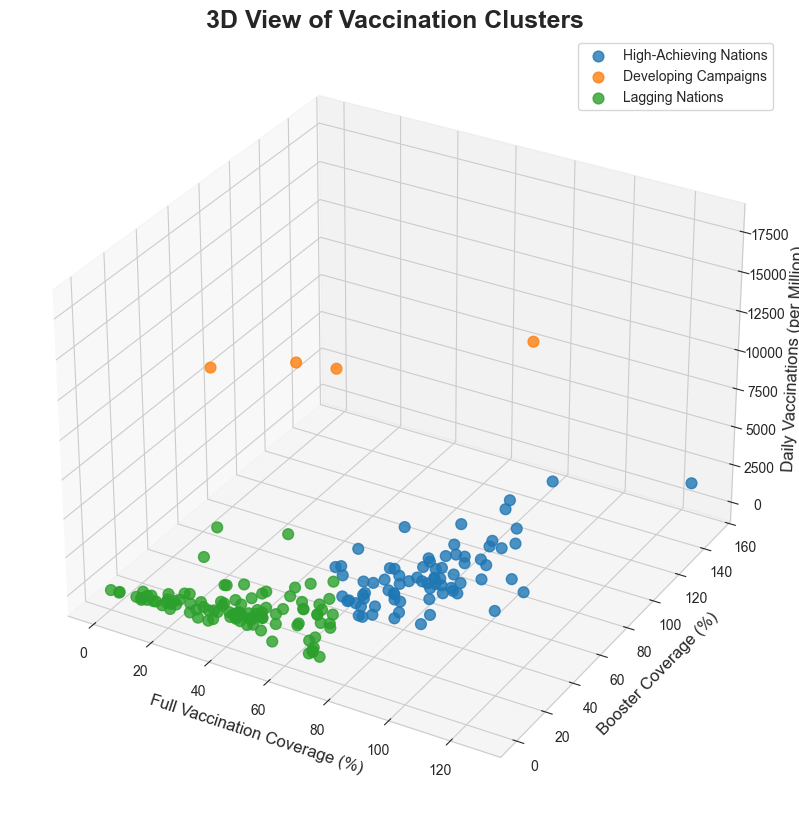

In [21]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot for each cluster
for cluster_num, name in cluster_names.items():
    cluster_data = cluster_df[cluster_df['cluster'] == cluster_num]
    ax.scatter(cluster_data['people_fully_vaccinated_per_hundred'], 
               cluster_data['total_boosters_per_hundred'], 
               cluster_data['daily_vaccinations_per_million'], 
               label=name, s=60, alpha=0.8)

ax.set_title('3D View of Vaccination Clusters', fontsize=18, weight='bold')
ax.set_xlabel('Full Vaccination Coverage (%)', fontsize=12)
ax.set_ylabel('Booster Coverage (%)', fontsize=12)
ax.set_zlabel('Daily Vaccinations (per Million)', fontsize=12)
ax.legend()
plt.show()

Model Insights: The clustering algorithm has successfully identified three distinct groups of countries based on their vaccination strategies and outcomes:

1. High-Achieving Nations: These countries show very high full vaccination and booster coverage. Their daily vaccination rate is moderate, suggesting their campaigns are in a mature, maintenance phase.

2. Developing Campaigns: This group has moderate vaccination and booster rates but a notably high daily vaccination rate. This indicates these nations are in the active, aggressive phase of their campaigns, working to catch up.

3. Lagging Nations: These countries are characterized by low levels across all three metrics: full vaccination, boosters, and daily vaccination speed. They represent nations where vaccination campaigns are still in the early stages or are facing significant challenges.